<h1 style="text-align: center;"> Striver - Sliding Window & 2-Pointer Combined Problems - Medium </h1>

# 1. Longest Substring without Repeating Characters :

## Problem Statement :

Given a string, S. Find the Length of the Longest Substring without repeating characters.


### Examples :

**Example 1:**
```
Input : S = "abcddabac"
Output : 4

Explanation : The answer is "abcd" , with a length of 4.
```

**Example 2:**
```
Input : S = "aaabbbccc"
Output : 2

Explanation : The answers are "ab" , "bc". Both have a maximum length of 2.
```

```
Constraints:
1 <= S.length <= 5*10^4
S contains only English lowercase letters.
```

# Brute Force Solution

## Intuition

The idea here is very straightforward - first generate all the possible substrings of given array using 2 for loops. While finding the substrings check if the current character has occured previously with the help of a Hash Array. If so, no need to take this substring into consideration as characters are repeating. Otherwise, calculate the length of the current substring, update maximum length and finally mark the character as visited.

## Approach

* Iterate through the array using a for loop from 0th index to sizeofArray - 1, to take all possible starting points of the substring into consideration.
* Check if the current character is already in the Hash Array, and if so, break out of the loop. Otherwise, as it is not visited yet, mark the character as 1 in the Hash Array, signifying that the current character is now visited.
* Now, calculate the Length of Current Substring and update the Maximum Length of the substrings found so far. Finally, return the Maximum Length.

## Brute Force Python Solution

In [1]:
class Solution:
    def longestNonRepeatingSubstring(self, s):
        # Length of the input string
        n = len(s)
        
        # Variable to store max length
        maxLen = 0
        
        """ Iterate through all possible 
            starting points of the substring """
        for i in range(n):
            
            """ Hash to track characters in 
                the current substring window """
            # Assuming extended ASCII characters
            hash_set = [0] * 256
            
            for j in range(i, n):
                
                """ If s[j] is already in the
                    current substring window """
                if hash_set[ord(s[j])] == 1:
                    break
                
                """ Update the hash_set to mark s[j]
                    as present in the current window """
                hash_set[ord(s[j])] = 1
                
                """ Calculate the length of
                    the current substring """
                current_len = j - i + 1
                
                """ Update maxLen if the current
                    substring length is greater """
                maxLen = max(maxLen, current_len)
        
        # Return the maximum length
        return maxLen

In [2]:
if __name__ == "__main__":
    
    input_str = "cadbzabcd"
    
    # Create an instance of Solution class
    sol = Solution()
    
    length = sol.longestNonRepeatingSubstring(input_str)
    
    # Print the result
    print("Length of longest substring without repeating characters:", length)

Length of longest substring without repeating characters: 5


## Complexity Analysis

**Time Complexity:**

The Time Complexity will be  O($N^2$), where N is the size of the array. This is because we are iterating the array twice using 2 for loops. 

**Space Complexity:**

The Space Complexity will be O(256) since we are using a Hash array to store all the characters.

# Optimal Solution

## Intuition

The idea is to use 2-pointers approach to solve this problem. The 2-pointer technique involves employing two indices, l (left) and r (right), which basically indicates a window starting from l and ending at r. Use a HashSet called set to keep track of characters within the current window (l to r). This allows for efficient checks and ensures no duplicates are present. While checking every window, keep track of the maximum length of subarray encountered so far.

## Approach

* Initialize few variables as: l and r pointers to 0. These pointers will define the current window [l, r] that contains characters without repetition, maxLen to 0 to store the maximum length of substring found without repeating character.
* Use an array hash of size 256 (assuming ASCII characters) to store the last occurrence index of each character in the string. Initialize all elements of hash to -1, indicating that no characters have been encountered yet.
* Now, while r pointer is less than sizeOfArray - 1, iterate in the array. While iterating, check if current character has occured before using Hash array. If so, update the left pointer to index of current character plus 1. This ensures that l moves past the last occurrence of of repeated character, effectively removing the repeated character from the window.
* Calculate the length of the current substring as len = r - l + 1. Update maximum length of the substring found so far.
* Update Hash array with the current index r, indicating the most recent occurrence of character at pointer r in the string. Finally, return maximum length of the substring.

## Dry Run

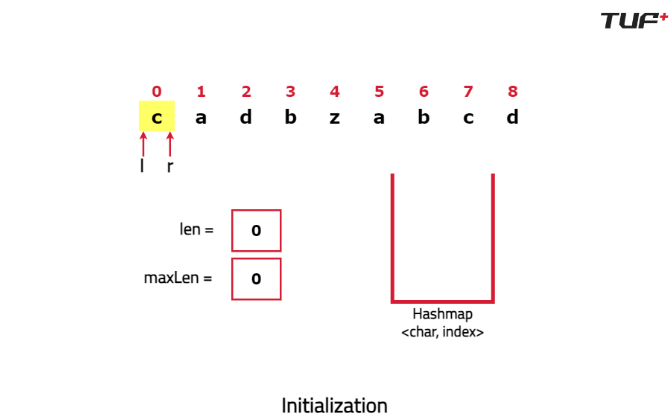
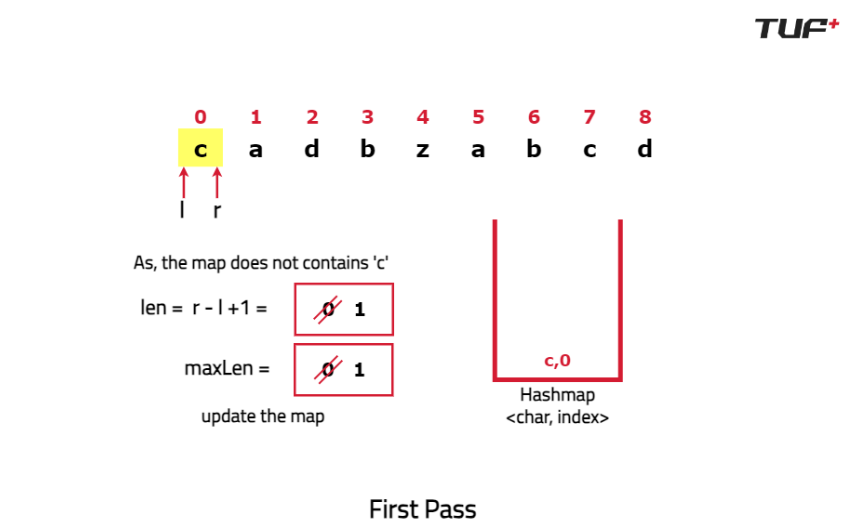
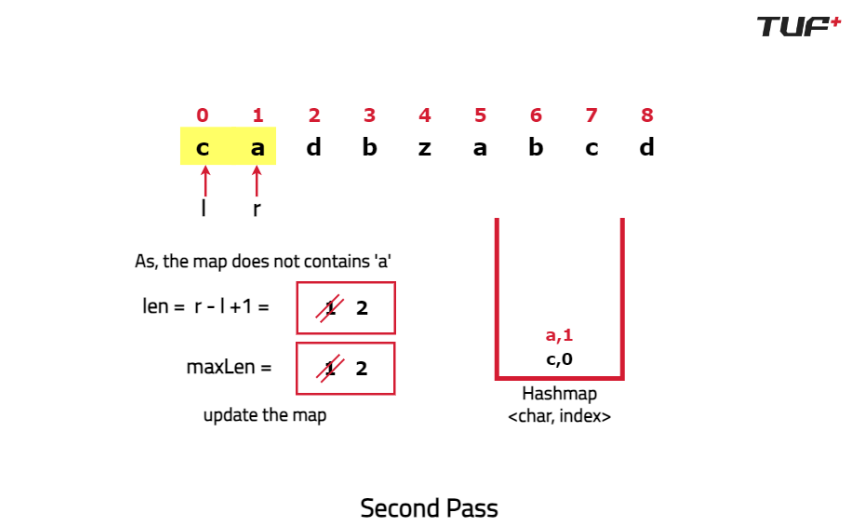
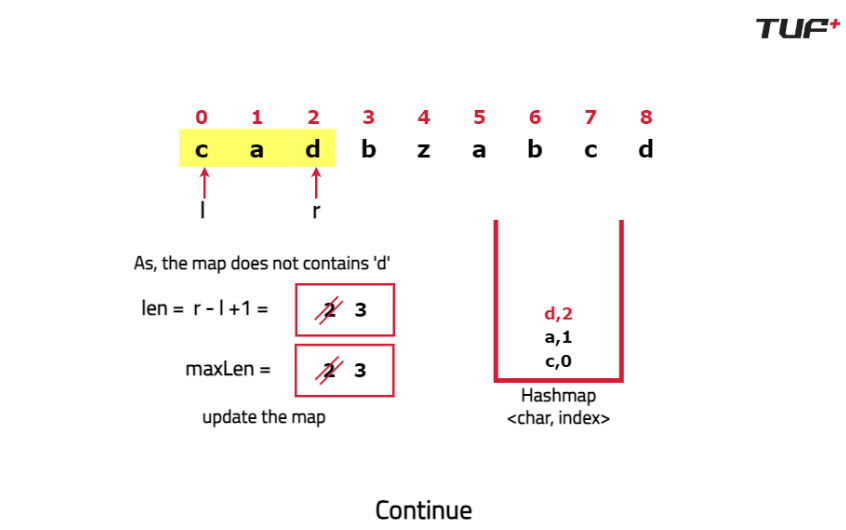
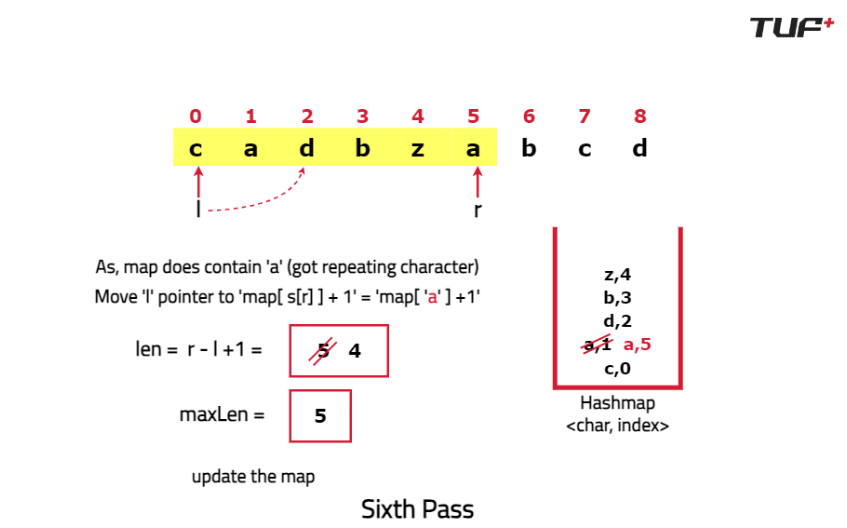
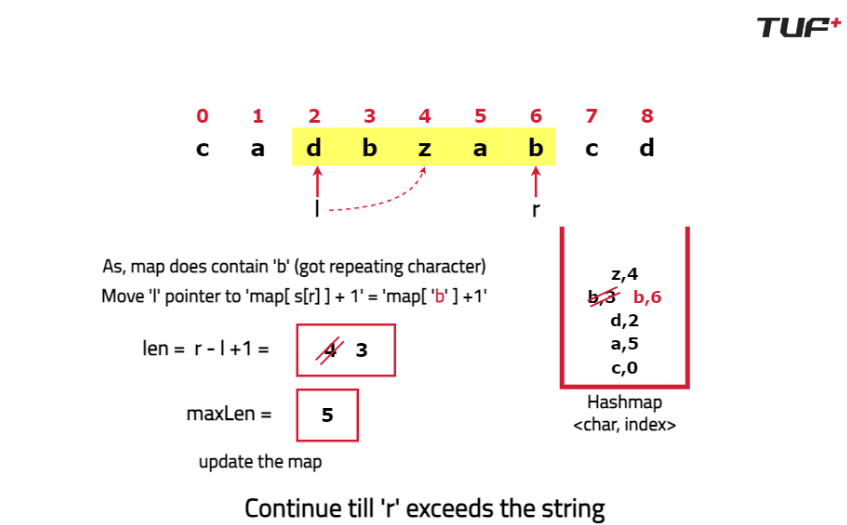

## Optimal Python Solution

In [3]:
class Solution:
    """ Function to find the longest substring
        without repeating characters """
    def longestNonRepeatingSubstring(self, s):
        n = len(s)
        
        # Assuming all ASCII characters
        HashLen = 256
        
        """ Hash table to store last
            occurrence of each character """
        hash = [-1] * HashLen

        l, r, maxLen = 0, 0, 0
        while r < n:
            """ If current character s[r] 
                is already in the substring """
            if hash[ord(s[r])] != -1:
                """ Move left pointer to the right
                    of the last occurrence of s[r] """
                l = max(hash[ord(s[r])] + 1, l)
            
            # Calculate the current substring length
            current_len = r - l + 1
            
            # Update maximum length found so far
            maxLen = max(current_len, maxLen)
            
            """ Store the index of the current
                character in the hash table """
            hash[ord(s[r])] = r
            
            # Move right pointer to next position
            r += 1
        
        # Return the maximum length found
        return maxLen

In [4]:
if __name__ == "__main__":
    s = "cadbzabcd"
    
    # Create an instance of the Solution class
    sol = Solution()

    result = sol.longestNonRepeatingSubstring(s)

    # Output the maximum length
    print("The maximum length is:")
    print(result)

The maximum length is:
5


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(N), where N is the size of the array as the array runs for N times.
```

**Space Complexity:**
```
The Space Complexity will be O(256) since we are using a Hash array to store all the characters.
```

## FAQs & Interview Follow-ups :

**What happens if the string contains spaces or special characters?**
```
Spaces and special characters are treated like any other character. They can be part of the substring as long as they are not repeated.
```

**Why use the sliding window approach?**
```
The Sliding Window ensures that the algorithm processes each character exactly once, avoiding redundant computations and maintaining a Time Complexity of O(N).
```

**How would you handle a case-insensitive string?**
```
Convert the string to lowercase (or uppercase) before processing to ensure consistency when checking for duplicates.
```

**What if you needed to return the substring itself instead of its length?**
```
Track the starting and ending indices of the longest substring during the traversal. Use these indices to extract the substring after completing the algorithm.
```

# 2. Max Consecutive Ones III :

## Problem Statement :

<b>Given a Binary Array nums and an integer k, flip at most k 0's.</b>

Return the Maximum Number of Consecutive 1's after performing the flipping operation.


### Examples :

**Example 1:**
```
Input : nums = [1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0] , k = 3
Output : 10

Explanation :
The Maximum Number of Consecutive 1's are obtained only if we flip the 0's present at position 3, 4, 5 (0 based indexing).
The Array after flipping becomes [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0].
The Number of Consecutive 1's is 10.
```

**Example 2:**
```
Input : nums = [0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1] , k = 3
Output : 9

Explanation :
The underlines 1's are obtained by flipping 0's in the new array.
The Array after flipping becomes [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1].
The Number of Consecutive 1's is 9.
```

**Example 3:**
```
Input: s = "openAI is innovative"
Output: "innovative is openAI"

```
```
Constraints:
1 <= nums.length <= 10^5
0 <= nums[i] <= 1
0 <= k <= nums.length
```

# Brute Force Solution

## Intuition

The idea here is to generate all possible substrings of the given array and while doing so, keep a track of all the zeros encountered so far in the substring. If the number of zeros exceeds k then there is no need to consider that substring, or else we can calculate the length of the current substring and update the Maximum Length of Substring.

## Approach

* Iterate the array using a for loop which runs from 0 to sizeOfArray - 1, which indicates the starting point of a substring. Now, initialize a variable zero to 0 to keep track number of zeros found so far in the substring.
* Use another for loop, which basically indicates the ending point of the substring, if the current element is 0, then increase the the variable zero by 1.
* If the number of 0s in the current substring exceeds k then break out of the inner loop, and we do not need to consider such a string. Else, calculate the length of current substring and update the maximum length of substring encountered so far. Finally, return the maximum length of the substring.

## Brute Force Python Solution

In [5]:
class Solution:
    """ Function to find the length of the
    longest substring with at most k zeros"""
    def longestOnes(self, nums, k):
        # Length of the input array
        n = len(nums)
        
        # Maximum length of the substring
        maxLen = 0
        
        """ Variable to count the number
        of zeros in the current window """
        zeros = 0
        
        """ Iterate through all possible 
        starting points of the substring """
        for i in range(n):
            zeros = 0
            
            """ Expand the window from starting
            point i to the end of the array """
            for j in range(i, n):
                if nums[j] == 0:
                    
                    """ Increment zeros count 
                    when encountering a zero """
                    zeros += 1
                
                """ If zeros count is within the 
                allowed limit (k), update maxLen """
                if zeros <= k:
                    
                    # Calculate the length of substring
                    length = j - i + 1
                    maxLen = max(maxLen, length)
                else:
                    break
        
        # Return the maximum length
        return maxLen

In [7]:
if __name__ == "__main__":
    input_arr = [1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0]
    k = 2
    
    # Create an instance of Solution class
    sol = Solution()
    
    length = sol.longestOnes(input_arr, k)
    
    # Print the result
    print(f"Length of longest substring with at most {k} zeros flipped: {length}")

Length of longest substring with at most 2 zeros flipped: 6


## Complexity Analysis

**Time Complexity:**

The Time Complexity will be  O($N^2$), where N is the size of the array. This is because for every element of the array the inner loop runs for N times.

**Space Complexity:**

The Space Complexity will be O(1) as no extra space is being used.

# Better Solution

## Intuition

The idea here is to use Sliding Window technique to solve this problem in Linear Time. The Sliding Window Technique is chosen because it efficiently manages a window within the input array that meets a specific criteria. It dynamically adjusts the size and position of the window based on the number of zeros encountered to ensure that the number of zeros are less than and equal to k.

## Approach

* First, initialize few variables as : l and r as pointers to the left and right ends of the window respectively, both starting at the beginning of the array nums. zeros is the variable to keep track of the number of zeros encountered within the current window and maxLen is to store the maximum length of the substring found so far.
* Use a Sliding Window approach where r moves from the start to the end of the array nums. Check if current element in the array is 0. If yes, increment the zeros count.
* While zeros exceeds k, adjust the window by moving l to the right until zeros is less than or equal to k. This ensures that the window contains at most k zeros.
* If number of zero is less than or equal to k then calculate the length of the substring. Update maximum length of sustring to keep track of the maximum length encountered during the iteration and finally, return it.

## Better Python Solution

In [8]:
class Solution:
    """ Function to find the length of the
    longest substring with at most k zeros """
    def longestOnes(self, nums, k):
        
        # Length of the input array
        n = len(nums)
        
        # Pointers for sliding window approach
        l, r = 0, 0
        
        """ Variables to count zeros
        and store maximum length """
        zeros, maxLen = 0, 0
        
        """ Iterate through the array 
        using sliding window approach """
        while r < n:
            if nums[r] == 0:
                
                """ Increment zeros count 
                when encountering a zero """
                zeros += 1  
            while zeros > k:
                if nums[l] == 0:
                    
                    """ Decrement zeros count
                    when moving left pointer """
                    zeros -= 1 
                
                """ Move left pointer to the
                right to shrink the window """
                l += 1  
            
            """ Calculate the length 
            of current substring """
            length = r - l + 1
            
            """ Update maxLen if the current
            substring length is greater """
            maxLen = max(maxLen, length)
            
            """ Move right pointer 
            to expand the window """
            r += 1  
        
        # Return the maximum length
        return maxLen

In [10]:
if __name__ == "__main__":
    
    input_arr = [1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0]
    k = 2  
    
    # Create an instance of Solution class
    sol = Solution()
    
    length = sol.longestOnes(input_arr, k)
    
    # Print the result
    print(f"Length of longest substring with at most {k} zeros flipped: {length}")

Length of longest substring with at most 2 zeros flipped: 6


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(2N), where N is the size of the array. This is because the outer and the inner loop is running for N times each.
```

**Space Complexity:**
```
The Space Complexity will be O(1) as no extra space is being used.
```

# Optimal Solution

## Intuition

The idea here is to employ the Sliding Window approach efficiently by avoiding the additional O(N) Time Complexity incurred when shifting the window entirely in the better solution, to ensure that the Total Number of zeros does not exceed k. <b>Instead of moving the left pointer (l) to eliminate excess zeros completely, shift the window by one position at a time. This method ensures that the problem can be solved in O(N) time complexity only. </b>

## Approach

* First, initialize few variables as: l and r as pointers, where l marks the left boundary and r marks the right boundary of the Sliding Window. zeros is the variable to count the number of zeros encountered within the current window, whereas maxLen is to store the Maximum Length of valid Substrings found.
* Use the r pointer to traverse through the array. For each element, check if it is 0. If so, increment the zeros count because we are adding one more zero to the current window.
* After incrementing zeros, check if zeros exceeds the allowed limit k. If so, adjust the window by moving the l pointer to the right until the window contains at most k zeros (zeros <= k). Decrement the zeros count accordingly when the element pointed by l is 0 and increment l.
* Whenever zeros is less than or equal to k, calculate the length of the current substring. Update maxLen to store the maximum length encountered so far among all valid substrings. Move r pointer by 1. Finally, return maxLen variable.

## Dry Run

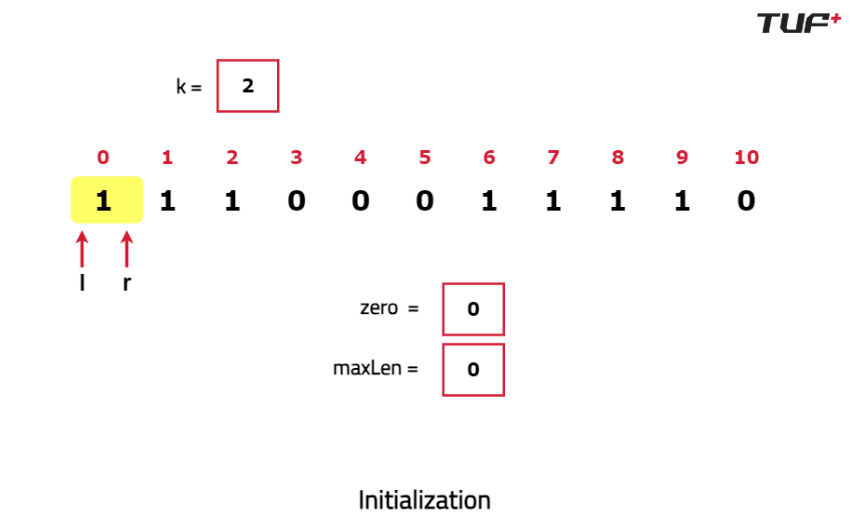
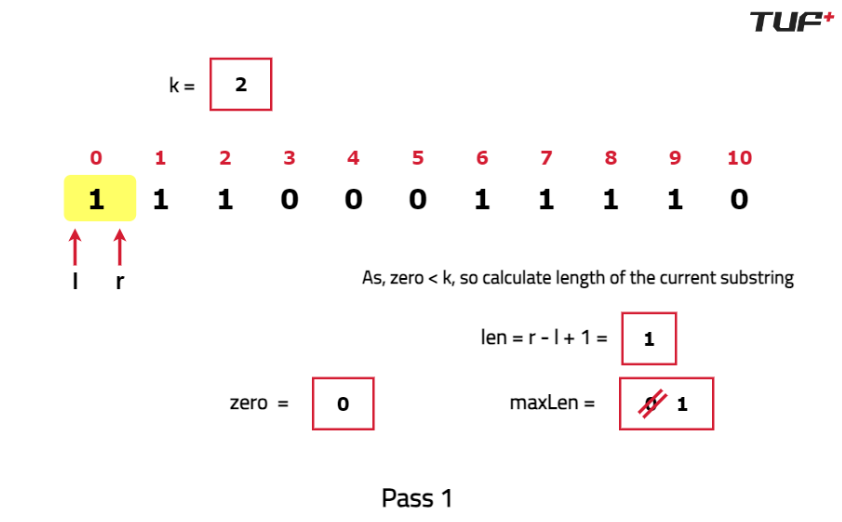
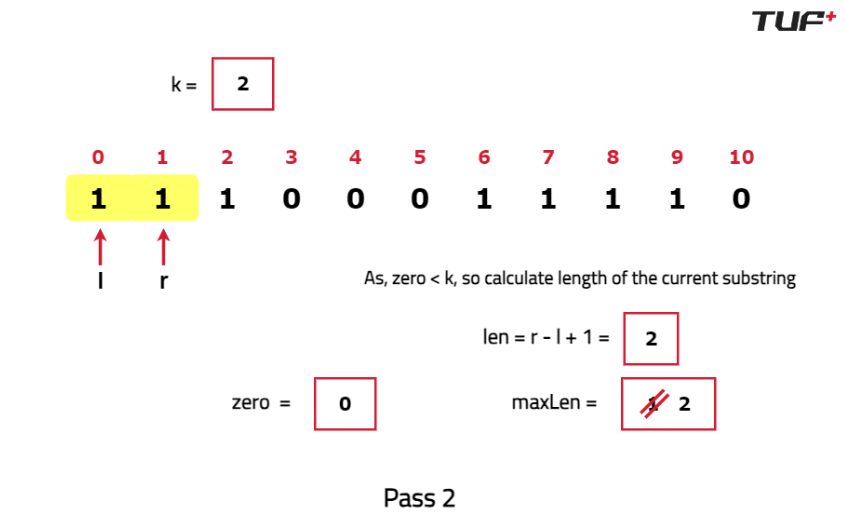
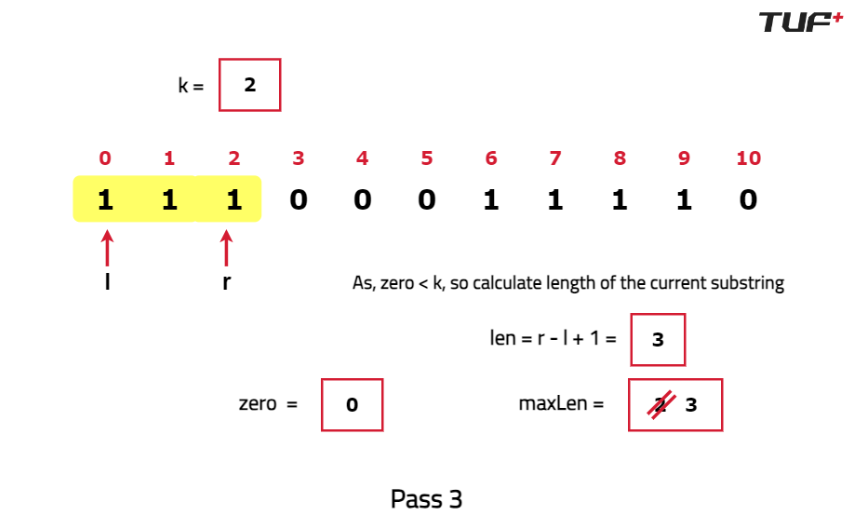
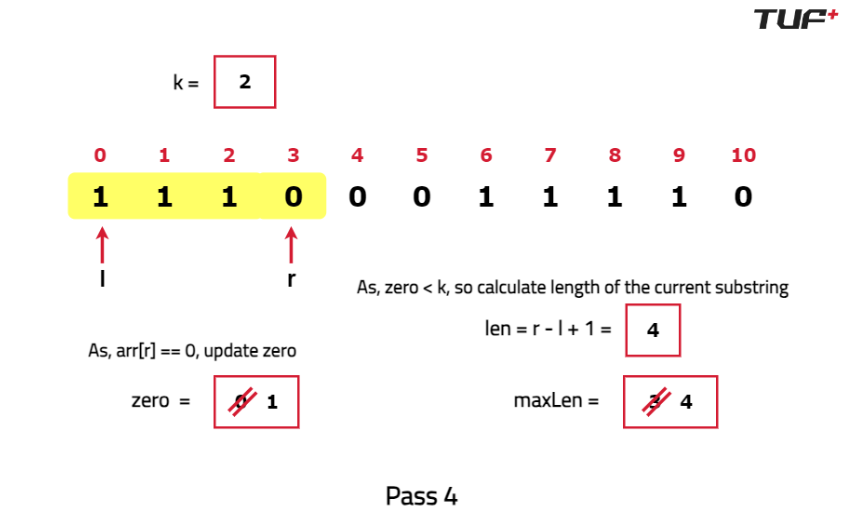

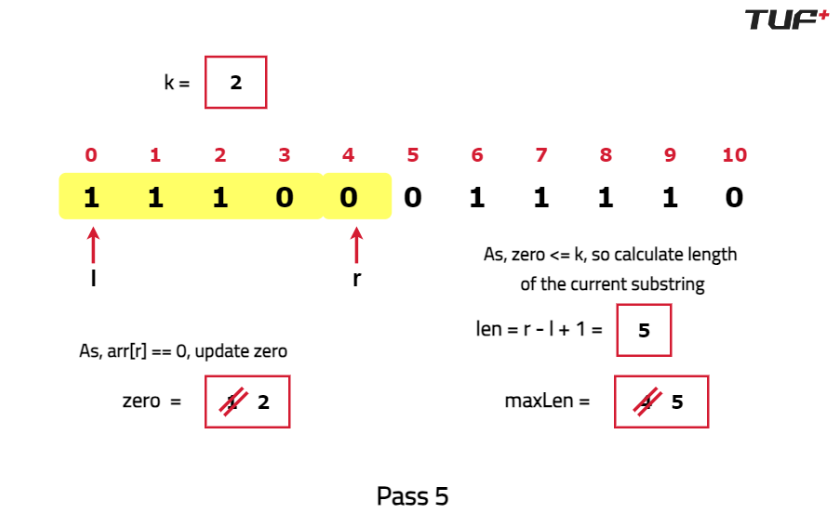
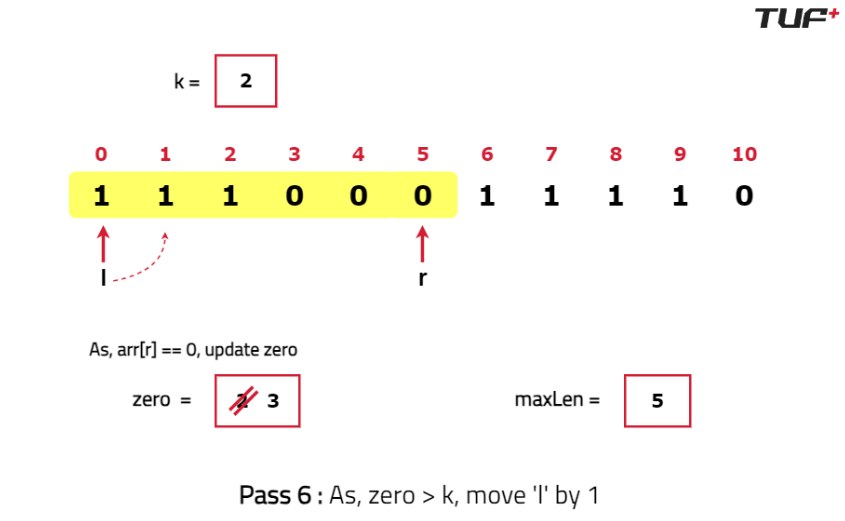
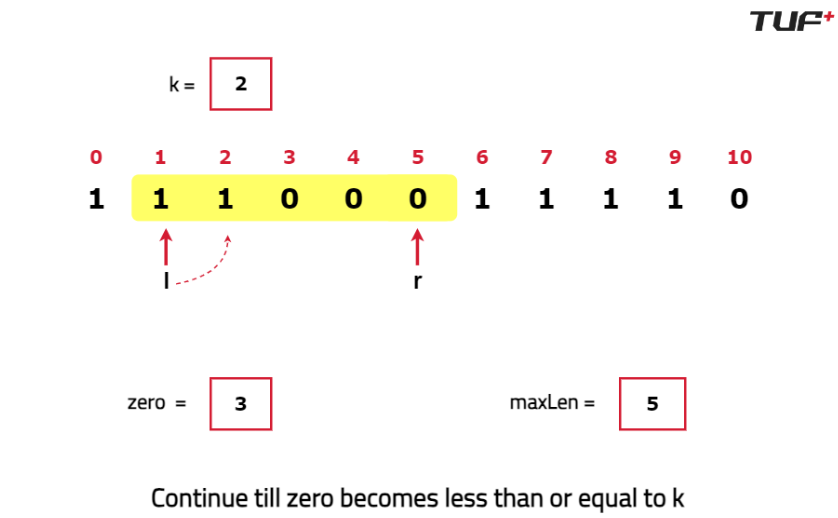
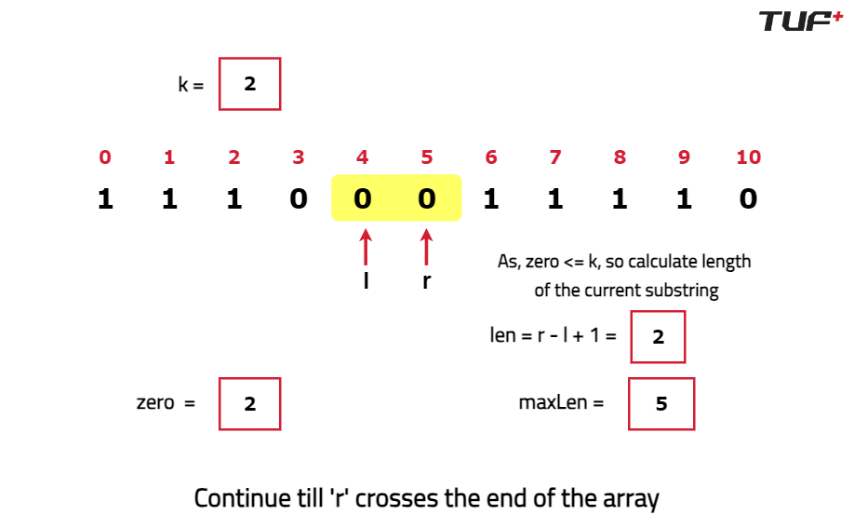
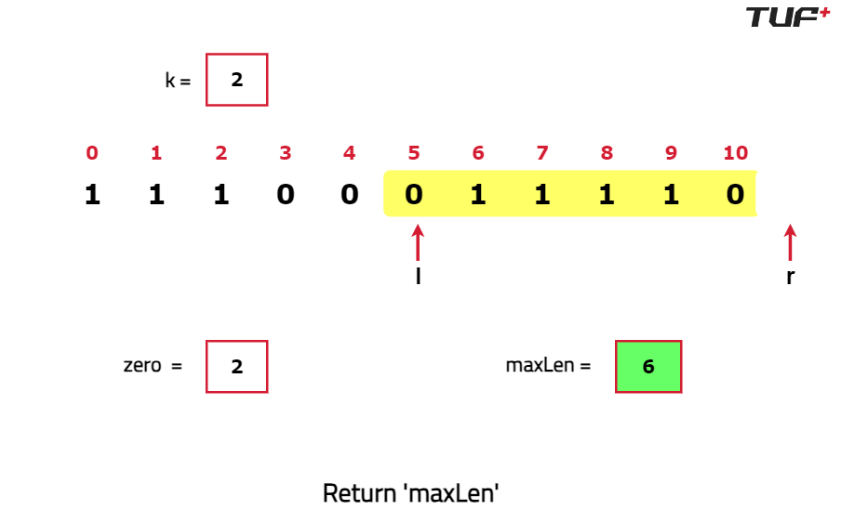

## Optimal Python Solution

In [11]:
class Solution:
    """ Function to find the length of the
    longest substring with at most k zeros """
    def longestOnes(self, nums, k):
        
        # Length of the input array
        n = len(nums)
        
        # Pointers for sliding window approach
        l, r = 0, 0
        
        """ Variables to count zeros
        and store maximum length """
        zeros, maxLen = 0, 0
               
        """ Iterate through the array 
        using sliding window approach """
        while r < n:
            
            if nums[r] == 0:
                zeros += 1
            
            if zeros > k:
                if nums[l] == 0:
                    
                    """ Decrement zeros count
                    when moving left pointer """
                    zeros -= 1 
                l += 1
            
            if zeros <= k:
                """ Calculate the length 
                of current substring """
                length = r - l + 1
            
                """ Update maxLen if the current
                substring length is greater """
                maxLen = max(maxLen, length)
            
            r += 1  
        
        # Return the maximum length
        return maxLen

In [12]:
if __name__ == "__main__":
    input_nums = [1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0]
    k = 2  
    
    # Create an instance of Solution class
    sol = Solution()
    
    length = sol.longestOnes(input_nums, k)
    
    # Print the result
    print(f"Length of longest substring with at most {k} zeros flipped: {length}")

Length of longest substring with at most 2 zeros flipped: 6


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(N), where N is the size of the array. This is because for every element, the loop only runs N times.
```

**Space Complexity:**
```
The Space Complexity will be O(1) as no extra space is being used.
```

## FAQs & Interview Follow-ups :

**What happens if nums contains no 0s?**
```
If the array contains no 0s, the entire array is already the longest subarray of consecutive 1s. The output will be n, where n is the length of the array.
```

**Can k be greater than the number of 0s in the array?**
```
Yes, in this case, all 0s can be flipped, and the result will be the length of the entire array, as all elements can become 1.
```

**How would you modify the solution to return the indices of the longest subarray?**
```
Track the start and end indices of the current window whenever a new Maximum Length is found. Return these indices along with the length.
```

**How would the problem change if flipping 1s into 0s were also allowed?**
```
Extend the logic to handle both flipping operations by maintaining separate counters for flipped 1s and 0s. Adjust the sliding window to ensure both constraints are satisfied.
```

# 3. Fruit into Baskets :

## Problem Statement :

There is only one row of fruit trees on the farm, oriented left to right. An integer array called fruits represents the trees, where fruits[i] denotes the kind of fruit produced by the ith tree.

The goal is to gather as much fruit as possible, adhering to the owner's stringent rules:

* There are 2 baskets available, and each basket can only contain 1 kind of fruit. The quantity of fruit each basket can contain is unlimited.
* Start at any tree, but as you proceed to the right, select exactly one fruit from each tree, including the starting tree. One of the baskets must hold the harvested fruits.
* Once reaching a tree with fruit that cannot fit into any basket, stop.

Return the Maximum Number of fruits that can be picked.

### Examples :

**Example 1:**
```
Input : fruits = [1, 2, 1]
Output : 3

Explanation :
We will start from the first tree.
The first tree produces the fruit of kind '1' and we will put that in the first basket.
The second tree produces the fruit of kind '2' and we will put that in the second basket.
The third tree produces the fruit of kind '1' and we have first basket that is already holding fruit of kind '1'. So we will put it in first basket.

Hence we were able to collect total of 3 fruits.
```

**Example 2:**
```
Input : fruits = [1, 2, 3, 2, 2]
Output : 4

Explanation :
We will start from the second tree.
The first basket contains fruits from second, fourth and fifth tree.
The second basket will contain fruit from the third tree.

Hence we collected a total of 4 fruits.
```

**Example 3:**
```
Input : fruits = [1, 2, 3, 4, 5]
Output: 2

```
```
Constraints:
1 <= fruits.length <= 10^5
0 <= fruits[i] < fruits.length
```

# Brute Force Solution

## Intuition

The idea here is to generate all possible substrings of the given array using 2 loops and while doing so, check if the number of different fruits is within the allowed limit in the current substring, using a set data structure. If the number of different fruits exceed limit, then no need to consider that substring, or else we calculate the length of the current substring and update the Maximum Length of the Substring.

## Approach

* Start by initializing variables n to store the length of the input array fruits, and maxLen to track the maximum length of substrings with at most 2 different types of fruits.
* Iterate the array for each index from 0 to sizeOfArray-1 to consider each index as the starting point of a substring.
* For each starting point, initialize an empty unordered_set named set to keep track of the types of fruits in the current substring and start another loop from starting point of the substring till sizeOfArray-1. Add each fruit to the set.
* After adding each fruit, check the size of the set. The set will only contain fruits that appear in the current substring.
* If the size of set is less than or equal to 2, it means the current substring has at most 2 different types of fruits. Calculate the length of this substring and update maxLen. Else, break out of the loop.
* After the outer and inner loops complete execution, return maxLen as an answer.

## Brute Force Python Solution

In [13]:
class Solution:
    """ Function to find the maximum
    fruits the basket can have """
    def totalFruits(self, fruits):
        
        # Length of the input array
        n = len(fruits)
        
        """ Variable to store the 
        maximum length of substring"""
        maxLen = 0
        
        """ Iterate through all possible 
        starting points of the substring"""
        for i in range(n):
            
            """ Use set to track
            different types of fruits"""
            s = set()
            
            for j in range(i, n):
                
                # Add fruit type to the set
                s.add(fruits[j])
                
                """ Check if the number of different
                fruits is within the allowed limit"""
                if len(s) <= 2:
                    
                    """ Calculate the length 
                    of current substring"""
                    length = j - i + 1
  
                    maxLen = max(maxLen, length)
                else:
                    break
        
        # Return the maximum length
        return maxLen

In [14]:
if __name__ == "__main__":
    input = [3, 3, 3, 1, 2, 1, 1, 2, 3, 3, 4]
    
    # Create an instance of Solution class
    sol = Solution()
    
    length = sol.totalFruits(input)
    
    # Print the result
    print("Maximum fruits in the basket is:", length)

Maximum fruits in the basket is: 5


## Complexity Analysis

**Time Complexity:**

The Time Complexity will be  O($N^2$), where N is the size of the array. This is because for every element of the array the inner loop runs for N times. Ignore the contribution of the Set data structure in the Time Complexity calculation as it takes O(log3), which can be considered as constant.

**Space Complexity:**

The Space Complexity will be O(3), as at most the Set data structure is holding 3 elements.

# Better Solution

## Intuition

The idea here is to use the Sliding Window approach with a HashMap data structure to keep track of the different types of the fruits found so far. Expand the window by moving the right pointer and if the the number of different types of fruits exceeds 2 then shrink the window until it becomes less than or equal to 2, thus eliminating fruits from the basket because of which the limit has exceed. This ensures to consider every possible case in an optimised way.

## Approach

* First, initialize few variables as: l, r as 0, maxLen variable to store the Maximum Length of Substrings with at most 2 different types of fruits, and mpp HashMap to track the count of each fruit type in the current sliding window defined by indices l (left) and r (right).
* Iterate through the array using the r pointer and add the current fruit to the HashMap mpp with its count incremented by one. Check if the number of different fruits exceeds 2. If it does, shrink the window from the left (l++) until the number of different fruits is at most 2. Else, Calculate the length of the current valid substring and update Maximum Length of Substring.
* Move the r pointer to the right (r++) to expand the window and repeat the process. Finally, return the Maximum Length of the Substring.

## Brute Force Python Solution

In [15]:
class Solution:
    """ Function to find the maximum
    fruits the basket can have """
    def totalFruits(self, fruits):
        
        # Length of the input array
        n = len(fruits)
        
        """ Variable to store the 
        maximum length of substring """
        maxLen = 0  
        
        """ Dictionary to track the count of each
        fruit type in the current window """
        mpp = {}
        
        # Pointers for the sliding window approach
        l, r = 0, 0
        
        while r < n:
            mpp[fruits[r]] = mpp.get(fruits[r], 0) + 1
            
            """ If number of different fruits exceeds
             2 shrink the window from the left """
            if len(mpp) > 2:
                while len(mpp) > 2:
                    mpp[fruits[l]] -= 1
                    if mpp[fruits[l]] == 0:
                        del mpp[fruits[l]]
                    l += 1
            
            """ If number of different fruits 
            is at most 2, update maxLen """
            if len(mpp) <= 2:
                maxLen = max(maxLen, r - l + 1)
            
            r += 1
        
        # Return the maximum fruit
        return maxLen

In [16]:
# Test the solution
if __name__ == "__main__":
    input = [3, 3, 3, 1, 2, 1, 1, 2, 3, 3, 4]
    
    # Create an instance of Solution class
    sol = Solution()
    
    length = sol.totalFruits(input)
    
    # Print the result
    print(f"Maximum fruits the basket can have: {length}")

Maximum fruits the basket can have: 5


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(2N), where N is the size of the array. This is because the other while loop runs for N time and the inner while loop runs for N time in total throghout the program. Ignore the contribution of Map Data Structure in the Time Complexity as size of the map is extremely small.
```

**Space Complexity:**
```
The Space Complexity will be O(3), as at most the Map Data Structure is holding 3 elements.
```

# Optimal Solution

## Intuition

The idea here is to employ the Sliding Window approach efficiently by avoiding the additional O(N) Time Complexity incurred when shifting the window entirely in the Better Solution, to ensure that the different types of fruits does not exceed 2. Instead of moving the left pointer (l) to eliminate the extra fruits completely, shift the window by one position at a time. This method ensures that the problem can be solved in O(N) Time Complexity only.

## Approach

* First, initialize few variables as: l and r pointers as 0 for the Sliding Window approach, maxLen variable to store the Maximum Length of Substrings with at most 2 different types of fruits, mpp as an unordered_map to track the count of each fruit type in the current Sliding Window.
* Iterate through the array using the r pointer and add the current fruit to the map with its count incremented by one.
* Check if the number of different fruits exceeds 2.If so, it means there are more than 2 different types of fruits in the current window. Therefore, shrink the window from the left (l++). Adjust the count in mpp accordingly. If the count of fruits[l] becomes 0, remove it from the map. Else, Calculate the Length of the Current Valid Substring.
* Update maxLen, move the r pointer to the right (r++) to expand the window and repeat the process. Finally, return the maxLen as an ans.

## Dry Run

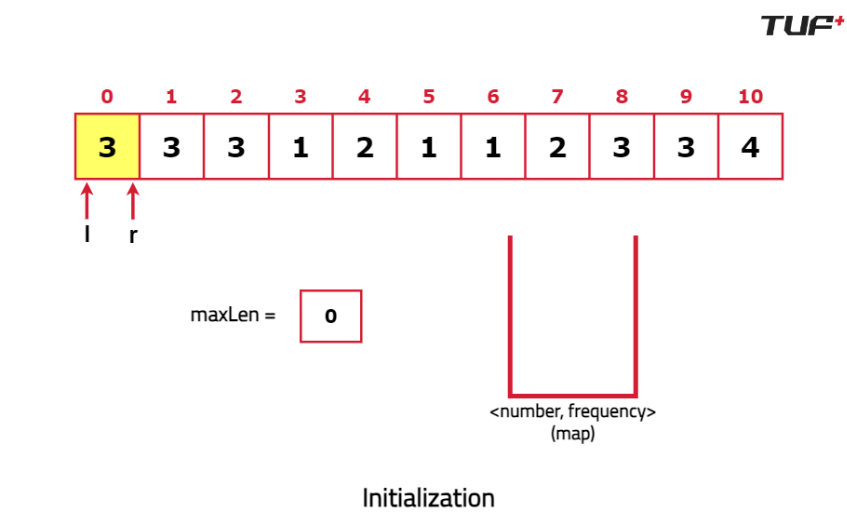
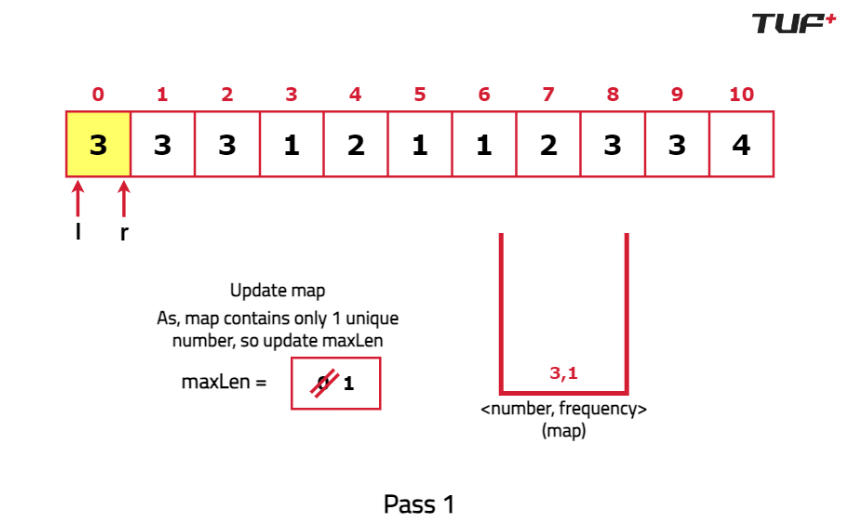
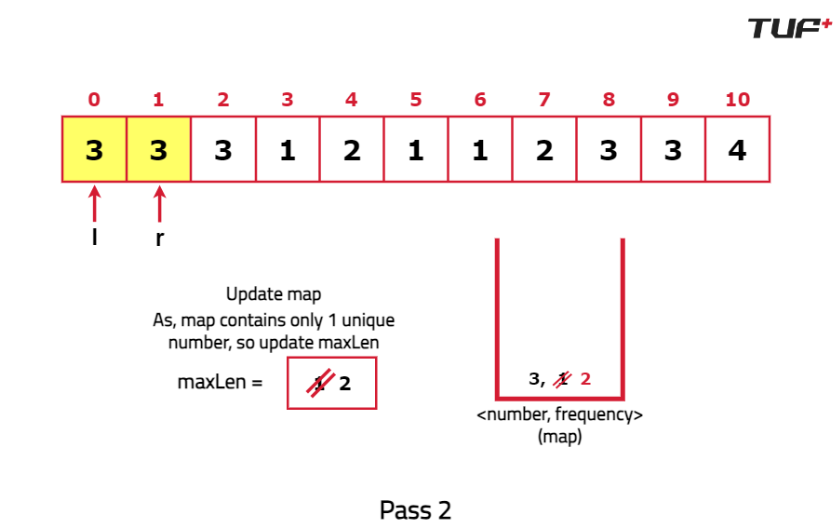
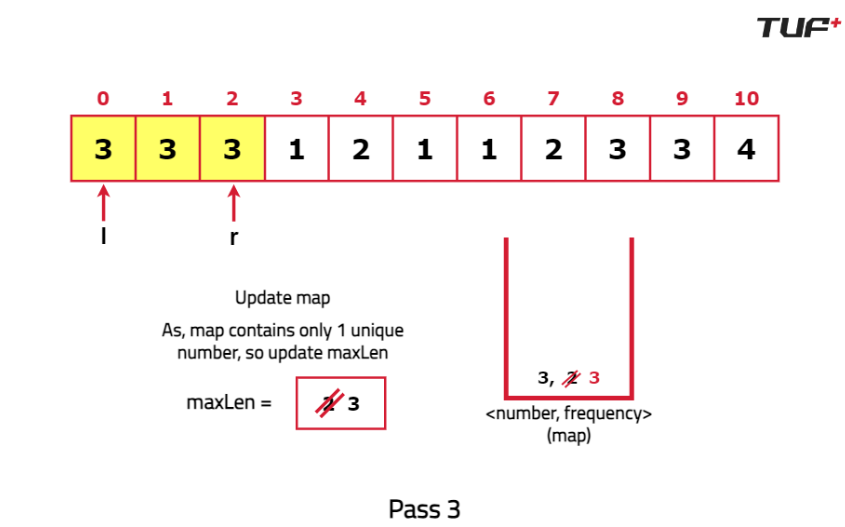
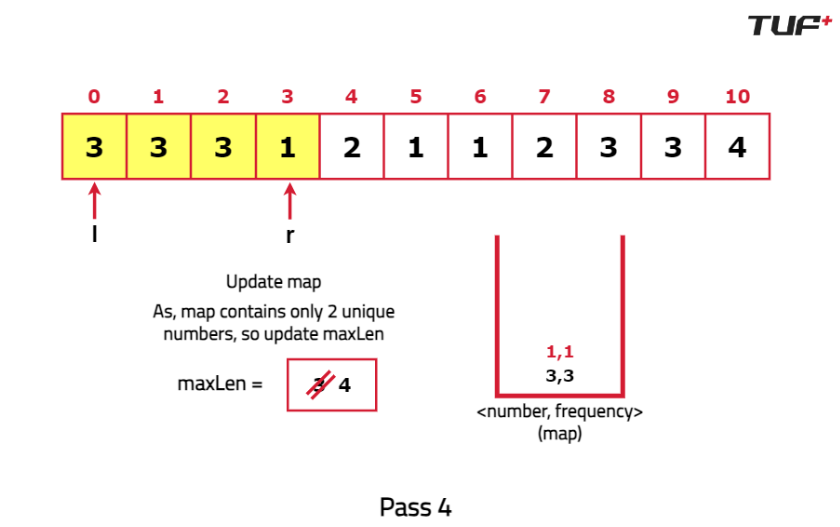

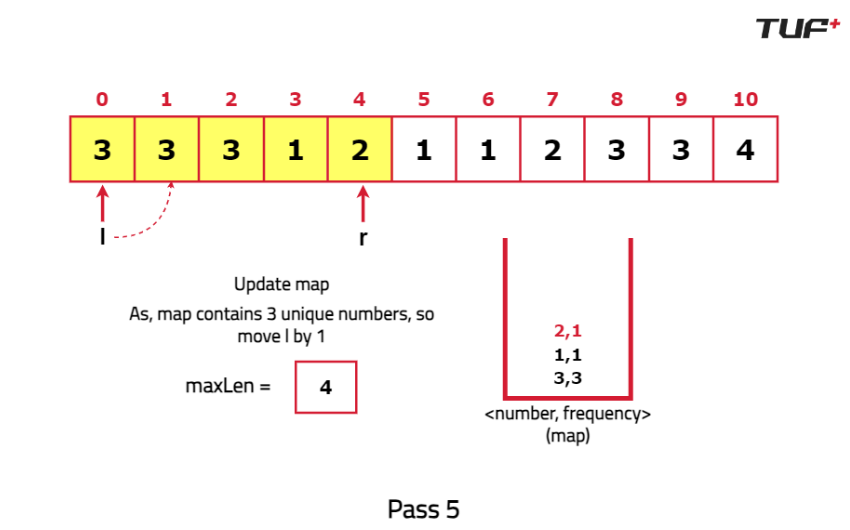
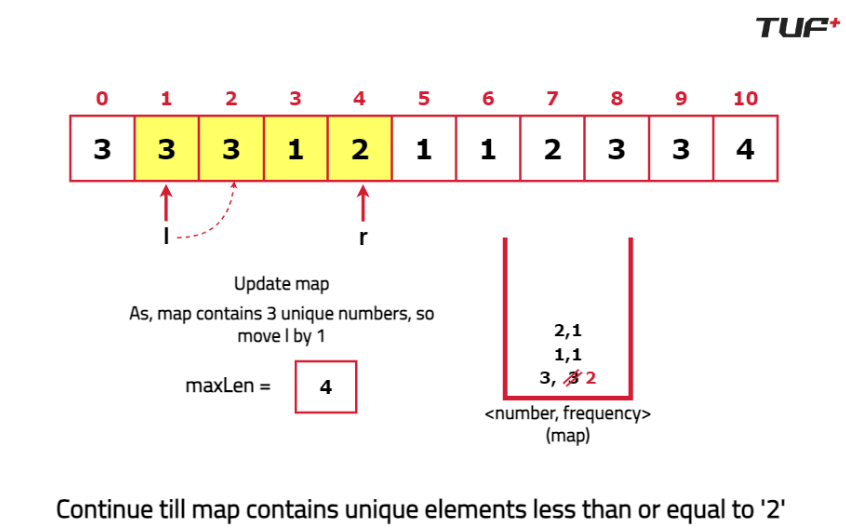
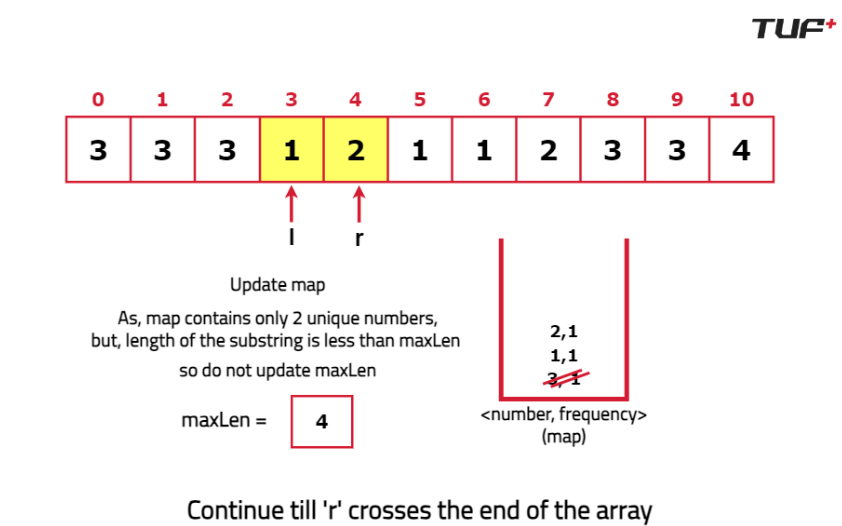
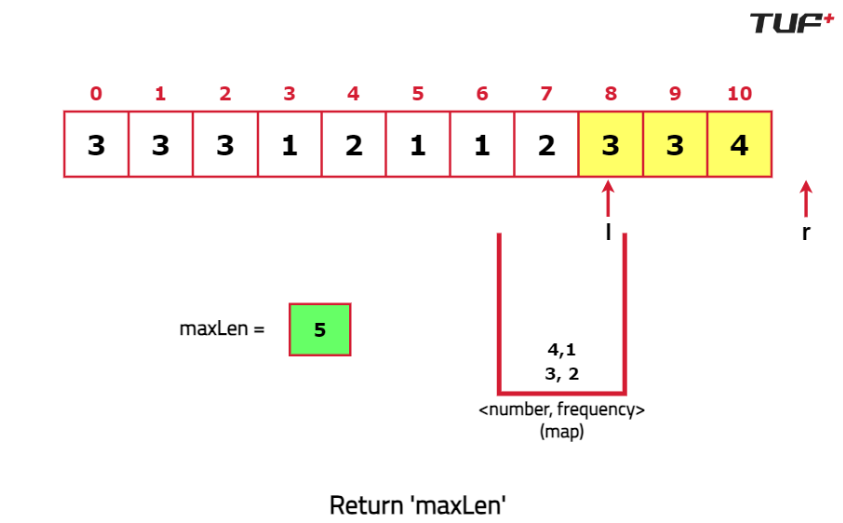

## Optimal Python Solution

In [17]:
class Solution:
    """ Function to find the maximum
    fruits the basket can have """
    def totalFruits(self, fruits):
        
        # Length of the input array
        n = len(fruits)
        
        """ Variable to store the 
        maximum length of substring """
        maxLen = 0  
        
        """ Dictionary to track the count of each
        fruit type in the current window """
        mpp = {}
        
        # Pointers for the sliding window approach
        l, r = 0, 0
        
        while r < n:
            mpp[fruits[r]] = mpp.get(fruits[r], 0) + 1
            
            """ If number of different fruits exceeds
             2 shrink the window from the left """
            if len(mpp) > 2:
                mpp[fruits[l]] -= 1
                if mpp[fruits[l]] == 0:
                    del mpp[fruits[l]]
                l += 1
            
            """ If number of different fruits 
            is at most 2, update maxLen """
            if len(mpp) <= 2:
                maxLen = max(maxLen, r - l + 1)
            
            r += 1
        
        # Return the maximum fruit
        return maxLen

In [18]:
if __name__ == "__main__":
    input = [3, 3, 3, 1, 2, 1, 1, 2, 3, 3, 4]
    
    # Create an instance of Solution class
    sol = Solution()
    
    len = sol.totalFruits(input)
    
    # Print the result
    print(f"Maximum fruits the basket can have: {len}")

Maximum fruits the basket can have: 5


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(N), where N is the size of the array. This is because the while loop runs for N time only. Ignore the contribution of map data structure in the Time Complexity as size of the map is extremely small.
```

**Space Complexity:**
```
The Space Complexity will be O(N), as the map may store up to N unique fruit types in the worst case.
```

## FAQs & Interview Follow-ups :

**What if there are fewer than three types of fruit?**
```
If the array contains fewer than three types, the entire array is valid, and the result is the length of the array.
```

**How is the Hash Map used to manage the Sliding Window?**
```
The Hash Map tracks the count of each fruit type in the current window. When a fruit type is removed (due to shrinking the window), its count is decremented, and it is removed from the Hash Map if the count reaches zero.
```

**How would you modify the solution if the number of baskets increased?**
```
Generalize the Sliding Window approach to handle k baskets by ensuring the Hash Map contains at most k fruit types at any time. The rest of the logic remains the same.
```

**What if you wanted to return the range of trees contributing to the maximum fruits?**
```
Along with tracking the maximum size, store the indices of the start and end of the window whenever the maximum is updated. Return these indices.
```

# 4. Longest Repeating Character Replacement :

## Problem Statement :

Given an integer k and a string s, any character in the string can be selected and changed to any other uppercase English character. This operation can be performed up to k times. After completing these steps, return the length of the longest substring that contains the same letter.


### Examples :

**Example 1:**
```
Input : s = "BAABAABBBAAA" , k = 2
Output : 6

Explanation :
We can change the B present at index 0 and 3 (0 based indexing) to A. The new string is "AAAAAABBBAAA".
The substring "AAAAAA" is the longest substring having same letter with length 6.
```

**Example 2:**
```
Input : s = "AABABBA" , k = 1
Output : 4

Explanation :
The underlined characters are changed in the new string obtained.
The new string is "AABBBBA". The substring "BBBB" is the answer.
There are other ways to achieve this answer as well.
```

**Example 3:**
```
Input : s = "AABABBA" , k = 1
Output : 4
```

```
Constraints:
1 <= s.length <= 10^5
0 <= k <= s.length
s contains only English uppercase letters.
```

# Brute Force Solution

## Intuition

The thought process is very straightforward - first find out each and every substring and while doing so, keep a track of characters and their frequencies. Further, calculate the number of characters that need to be changed, and if it is greater than the given limit then no need to consider that substring. Otherwise calculate the maximum length of the substring encountred so far.

## Approach

* First, initialize few variables: maxLen as 0 to track the Maximum Length found and maxFreq as 0 to track the highest frequency of any single character in the current window.
* Iterate through the array, which will basically be the starting point of the substring. For each starting index, initialize a frequency array hash to count occurrences of characters.
* Update max frequency encountered and store it in maxFreq variable. Calculate the number of changes needed to make.
* If the number of changes is less than or equal to k, update maxLen with the size of the current valid window. If the number of changes exceed k, break out of the inner loop since further expanding the window won't help in achieving a valid substring. Finally return the maxLen as a answer.

## Brute Force Python Solution

In [25]:
import builtins
len = builtins.len
range = builtins.range

class Solution:
    """
    Function to find the longest substring
    with at most k characters replaced.
    """
    def characterReplacement(self, s: str, k: int) -> int:

        n = len(s)
        """ Variable to store the maximum
        length of substring found"""
        maxLen = 0
        
        """ Variable to track the maximum frequency of
        any single character in the current window"""
        maxFreq = 0

        # Iterate through each starting point of the substring
        for i in range(n):
            
            # Initialize hash array for character frequencies
            hash = [0] * 26

            for j in range(i, n):
                
                """ Update frequency of current
                character in the hash array"""
                hash[ord(s[j]) - ord('A')] += 1

                # Update max frequency encountered
                maxFreq = max(maxFreq, hash[ord(s[j]) - ord('A')])

                # Calculate the number of changes needed to make
                changes = (j - i + 1) - maxFreq

                """ If the number of changes is less than or 
                equal to k, the current window is valid"""
                if changes <= k:
                    maxLen = max(maxLen, j - i + 1)
                else:
                    break

        """ Return the maximum length of substring
        with at most k characters replaced"""
        return maxLen

In [26]:
if __name__ == "__main__":
    s = "AABABBA"
    k = 2
    
    # Create an instance of Solution class
    sol = Solution()
    
    length = sol.characterReplacement(s, k)
    
    # Print the result
    print(f"Maximum length of substring with at most {k} characters replaced: {length}")

Maximum length of substring with at most 2 characters replaced: 5


## Complexity Analysis

**Time Complexity:**

The Time Complexity will be O($N^2$), where N is the size of the array. This is because we are iterating the array twice using two for loops.

**Space Complexity:**

The Space Complexity will be O(26) since we are using a Hash array to store the frequencies of the capital letters.

# Better Solution

## Intuition

The idea here is to use the Sliding Window technique to solve this problem optimally. This method efficiently finds the Longest Substring with Frequency Counting and Dynamic Adjustments to ensure validity of the window. First expand the window and add those substrings that validate the condition and when it crosses the limit, again shrink the window by moving the left pointer. This process ensures to provide a Linear Time Complexity.

## Approach

* First initialize few variables: l (left) and r (right) as 0 to define the current window in the string, maxLen as 0 to track the Maximum Length of valid substrings, and maxFreq as 0 to Monitor the Highest Frequency of any Single Character within the current window. Also, maintain a frequency array hash to count occurrences of characters.
* Incrementally expand the window by moving the r pointer to the right. Update the Frequency of the Current Character in Hash and adjust maxFreq if this frequency exceeds the current maxFreq.
* Check if the number of characters that need replacement exceeds k. If so, slide the l pointer to the right until the window becomes valid again. Adjust the frequencies in hash and update maxFreq accordingly.
* After ensuring the window is valid, update maxLen with the length of the current window. Finally, return maxLen, which holds the length of the longest substring.

## Better Python Solution

In [27]:
class Solution:
    """
    Function to find the longest substring 
    with at most k characters replaced
    """
    def characterReplacement(self, s: str, k: int) -> int:
        
        """ Variable to store the maximum
        length of substring found"""
        maxLen = 0
        
        """ Variable to track the maximum frequency
        of any single character in the current window"""
        maxFreq = 0
        
        # Pointers to maintain the current window [l, r]
        l = 0
        r = 0
        
        # Hash array to count frequencies of characters
        hash = [0] * 26

        # Iterate through each starting point of substring
        while r < len(s):
            
            """ Update frequency of current
            character in the hash array"""
            hash[ord(s[r]) - ord('A')] += 1
            
            # Update max frequency encountered
            maxFreq = max(maxFreq, hash[ord(s[r]) - ord('A')])
            
            # Check if current window is invalid
            while (r - l + 1) - maxFreq > k:
                
                """ Slide the left pointer to
                make the window valid again"""
                hash[ord(s[l]) - ord('A')] -= 1
                
                # Recalculate maxFreq for current window
                maxFreq = 0
                for i in range(26):
                    maxFreq = max(maxFreq, hash[i])
                
                # Move left pointer forward
                l += 1
            
            """ Update maxLen with the length
            of the current valid substring"""
            maxLen = max(maxLen, r - l + 1)
            
            # Move right pointer forward to expand window
            r += 1

        """ Return the maximum length of substring
        with at most k characters replaced"""
        return maxLen

In [28]:
if __name__ == "__main__":
    s = "AABABBA"
    k = 2

    # Create an instance of Solution class
    sol = Solution()

    length = sol.characterReplacement(s, k)

    # Print the result
    print(f"Maximum length of substring with at most {k} characters replaced: {length}")

Maximum length of substring with at most 2 characters replaced: 5


## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O((N+N) * 26), where N is the size of the array. The right pointer runs for N times and the left pointer runs for N times throughout. The for loop takes extra O(26) to claculate the maximum frequency.
```

**Space Complexity:**
```
The Space Complexity will be O(26) as we are using a Hash array to store all the characters.
```

# Optimal Solution

## Intuition

The idea here is to use the Sliding Window approach by avoiding the additional O(N) Time Complexity incurred when shifting the window entirely in the Better solution, to ensure that no more than k characters gets replaced in the current substring. Instead of moving the left pointer (l) completely till the distinct character comes under given limit, shift the window by one position at a time. This way the extra while loop used in the Better approach can be eliminated.

## Approach

* First, initialize few variables: l (left) and r (right) as 0 to define the current window in the string, maxLen as 0 to track the maximum length of valid substrings. Also, maintain a Frequency Array Hash to count occurrences of characters.
* Incrementally expand the window by moving the r pointer to the right. Update the frequency count of current character. Track the Maximum Frequency encountered (maxFreq) within the current window.
* If the length of the current window minus maxFreq exceeds k, the window becomes invalid. Slide the l pointer to the right to shrink the window by one position by decrementing the frequency count of character at the left pointer.
* After ensuring the window is valid, update maxLen with the length of the current window. Continue this process until the r pointer reaches the end of the string and finally, return maxLen as an answer.

## Dry Run

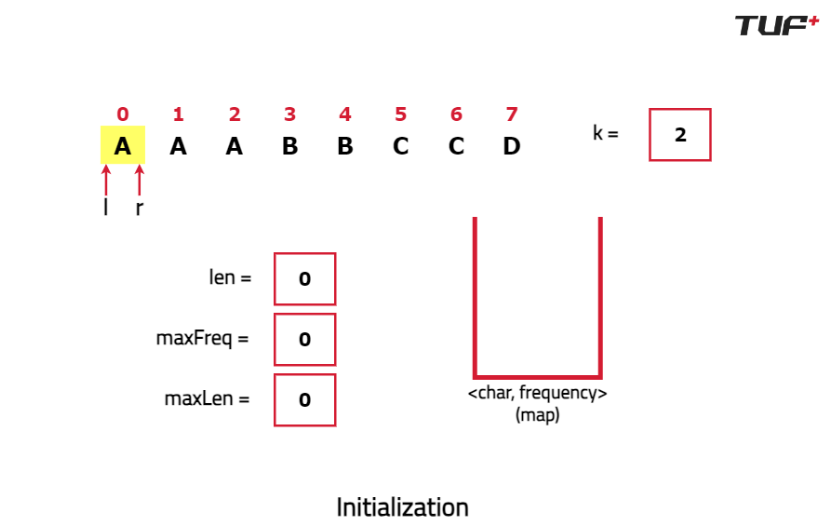
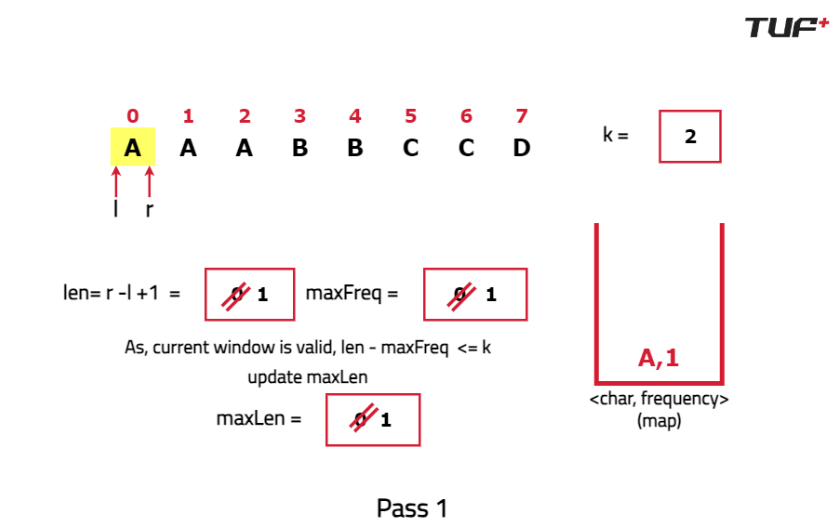
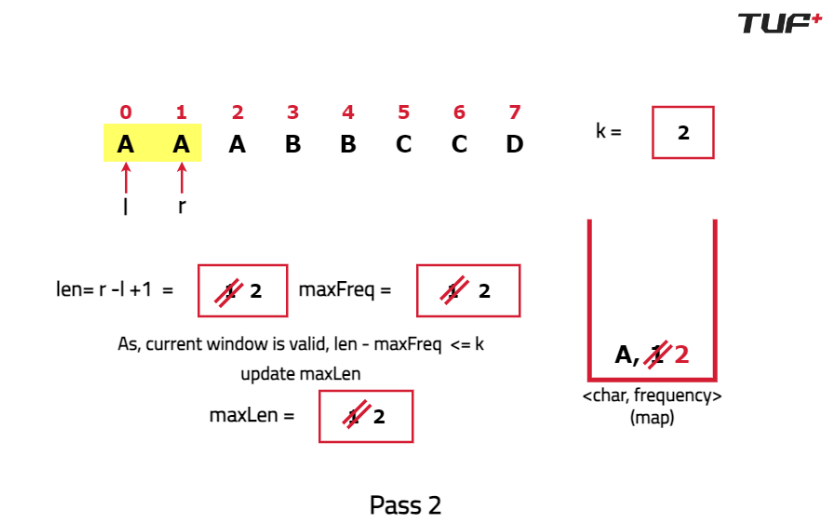
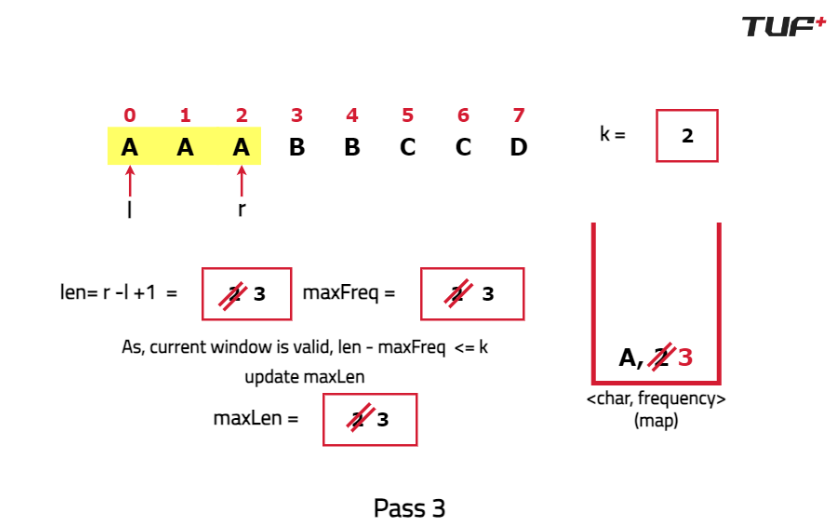
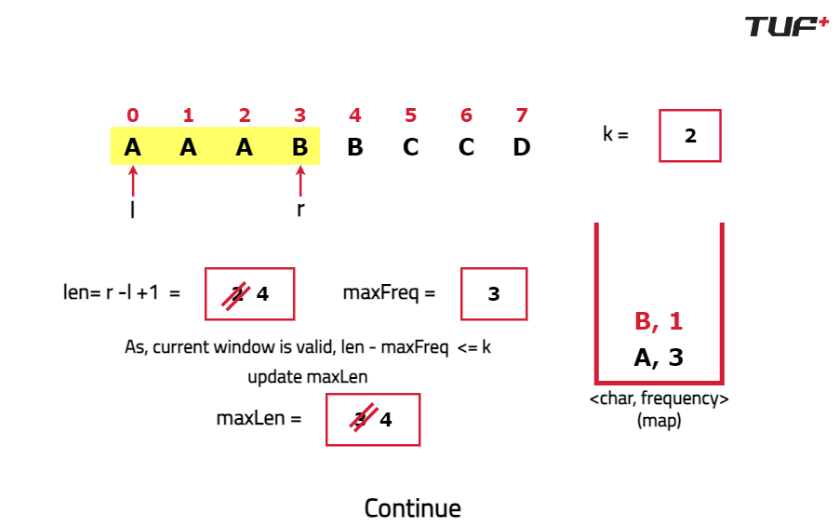

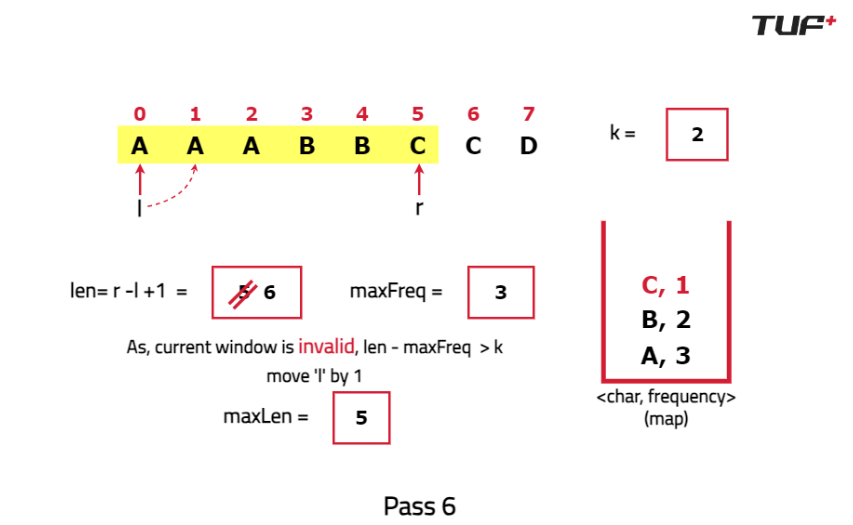
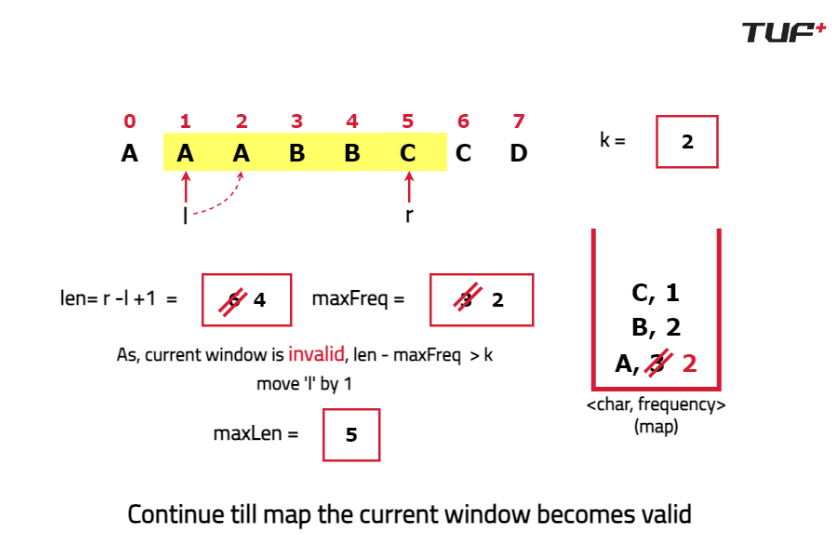
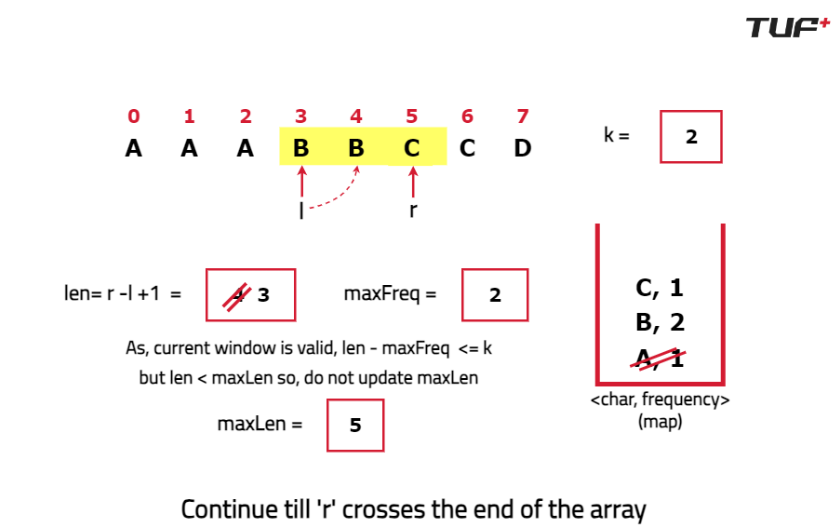

## Optimal Python Solution

In [ ]:
class Solution:
    """
    Function to find the longest substring 
    with at most k characters replaced
    """
    def characterReplacement(self, s: str, k: int) -> int:
        
        """ Variable to store the maximum
        length of substring found"""
        maxLen = 0
        
        """ Variable to track the maximum frequency
        of any single character in the current window"""
        maxFreq = 0
        
        # Pointers to maintain the current window [l, r]
        l = 0
        r = 0
        
        # Hash array to count frequencies of characters
        hash = [0] * 26

        # Iterate through each starting point of substring
        while r < len(s):
            
            """ Update frequency of current
            character in the hash array"""
            hash[ord(s[r]) - ord('A')] += 1
            
            # Update max frequency encountered
            maxFreq = max(maxFreq, hash[ord(s[r]) - ord('A')])
            
            # Check if current window is invalid
            if (r - l + 1) - maxFreq > k:
                
                """ Slide the left pointer to
                make the window valid again"""
                hash[ord(s[l]) - ord('A')] -= 1
                
                # Move left pointer forward
                l += 1
            
            """ Update maxLen with the length
            of the current valid substring"""
            maxLen = max(maxLen, r - l + 1)
            
            # Move right pointer forward to expand window
            r += 1

        """ Return the maximum length of substring
        with at most k characters replaced"""
        return maxLen

In [ ]:
if __name__ == "__main__":
    s = "AABABBA"
    k = 2

    # Create an instance of Solution class
    sol = Solution()

    length = sol.characterReplacement(s, k)

    # Print the result
    print(f"Maximum length of substring with at most {k} characters replaced: {length}")

## Complexity Analysis

**Time Complexity:**
```
The Time Complexity will be O(N), where N is the size of the array. The right pointer runs for N times.
```

**Space Complexity:**
```
The Space Complexity will be O(26) since we are using a Hash array to store all the characters.
```

## FAQs & Interview Follow-ups :

**How is the replacement count calculated?**
```
The replacement count for a window is the total number of characters in the window minus the frequency of the most common character. This represents the number of characters that need to be changed.
```

**What happens if all characters in the string are the same?**
```
If all characters are identical, the entire string is valid without any replacements. The output is the length of the string.
```

**How would you handle lowercase letters or a mix of uppercase and lowercase?**
```
Adjust the frequency map to account for 52 characters (26 lowercase + 26 uppercase), or normalize the case before processing.
```

**What if you wanted to return the actual substring instead of its length?**
```
Track the start and end indices of the window whenever a new maximum length is found. Use these indices to extract the substring after completing the algorithm.
```